# Black Beauty Book Analysis of sentiment

In [ ]:
import requests
import pandas as pd
import numpy as np
import re
import nltk as nltk
import matplotlib.pyplot as plt

texts_url = {'Black Beauty': 'https://www.gutenberg.org/cache/epub/271/pg271.txt'}

In [3]:
from bs4 import BeautifulSoup
def scrape(url):
    try:
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        return str(soup)
    except Exception as e:
        return f"Scrape failed"

In [4]:
from nltk.tokenize import sent_tokenize
def clean_black_beauty(text):
    text = text.split('Part I\n')[-1]
    text=text.split('*** END OF THE PROJECT GUTENBERG EBOOK BLACK BEAUTY ***')[0]
    text = text.replace('\r\n', '\n')
    text = re.sub(r'\n+Part [IVXLCDM]+\n+', '\n', text)
    chapter_titles = re.findall(r'\n+(\d{2} [^\n]+)\n+', text)
    chapters = re.split(r'\n+\d{2} [^\n]+\n+', text)
    chapters = [re.sub(r'\s+', ' ', chapter).strip() for chapter in chapters if chapter.strip()]
    chapters = [sent_tokenize(part) for part in chapters]
    return dict(zip(chapter_titles, chapters[1:]))
Black_beauty_text = clean_black_beauty(scrape('https://www.gutenberg.org/cache/epub/271/pg271.txt'))


In [5]:
Black_beauty_df = pd.DataFrame(data = Black_beauty_text.items(), columns=['Chapter title', 'text'])
Black_beauty_df

,Chapter title,text
0,01 My Early Home,[The first place that I can well remember was ...
1,02 The Hunt,[Before I was two years old a circumstance hap...
2,03 My Breaking In,[I was now beginning to grow handsome; my coat...
3,04 Birtwick Park,[At this time I used to stand in the stable an...
4,05 A Fair Start,[The name of the coachman was John Manly; he h...
5,06 Liberty,"[I was quite happy in my new place, and if the..."
6,07 Ginger,[One day when Ginger and I were standing alone...
7,08 Ginger's Story Continued,[The next time that Ginger and I were together...
8,09 Merrylegs,"[Mr. Blomefield, the vicar, had a large family..."
9,10 A Talk in the Orchard,[Ginger and I were not of the regular tall car...


In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
SIA = SentimentIntensityAnalyzer()
def average_sentiment(sentences):
    s_scores = [SIA.polarity_scores(s) for s in sentences]
    return pd.Series({k: sum(score[k] for score in s_scores) / len(s_scores) for k in ['neg', 'neu', 'pos', 'compound']})
Black_beauty_df[['neg', 'neu', 'pos', 'compound']] = Black_beauty_df['text'].apply(average_sentiment)

In [7]:
Black_beauty_df.head()

,Chapter title,text,neg,neu,pos,compound
0,01 My Early Home,[The first place that I can well remember was ...,0.023469,0.848625,0.127906,0.274800
1,02 The Hunt,[Before I was two years old a circumstance hap...,0.055068,0.910227,0.034705,-0.090261
2,03 My Breaking In,[I was now beginning to grow handsome; my coat...,0.076209,0.814047,0.109721,0.046279
3,04 Birtwick Park,[At this time I used to stand in the stable an...,0.048171,0.828400,0.123371,0.209431
4,05 A Fair Start,[The name of the coachman was John Manly; he h...,0.027730,0.847189,0.125081,0.366070


## Analysis
The Neutral score for this book seems to be ranging from 0.8 to 0.9 for the entirety of the book, making it have pretty neutral language throught the book. However, the compound score has a large range from -0.17 to +0.42, meaning the overall sentiment throughout the story changed a lot. Chapters 5, 6, 7, and 34-37 are relatively positive whereas chapters 39, 40, 48, and 49 are relatively negative. This makes sense because chapters 39 and 40 are where the main charater's best friend is found dead. Chatper 48 is where the main character is exhausted and put up for auction. Chapter 49 however doesn't make sense, because this is the conclusion of the story where the main character finds his forever home. Chapters 5, 6, and 7 make sense because they are about him settling into his new life under the care of a kind coachmen, feeling free to gallop in the grass, and making a new friend. Chapters 34-37 also make sense, because the main character is settling into his job as a cab horse under what he describes as a kind man. 

To conclude, the sentiment of Black Beauty fluctuates substantially between chapters rather than following a consistent positive or negative trend. Most of the language is classified as neutral, however the compound sentiment reveals several pronounced emotional shifts, including strongly positive sections early and midway through the novel, a substantial negative shift around Chapters 39–40, and a return to positive sentiment in the final chapters.

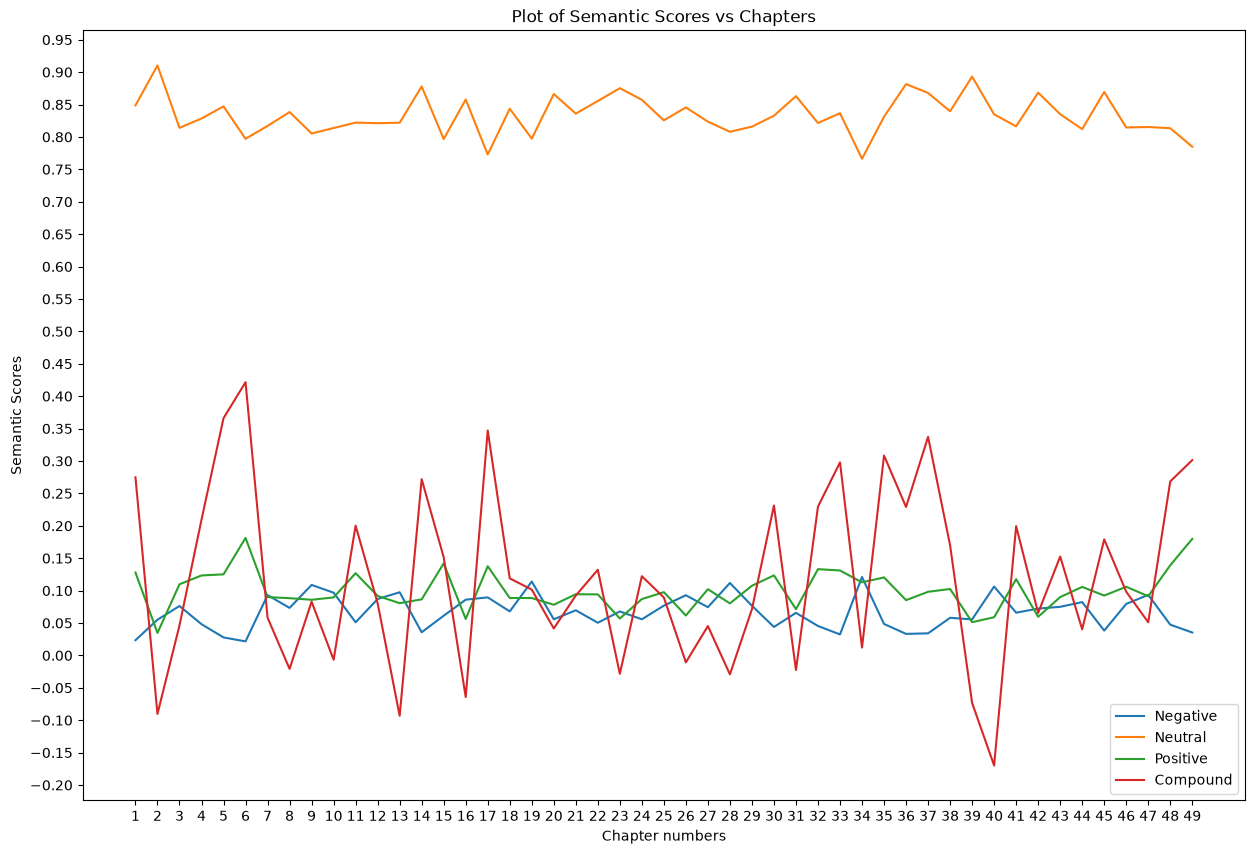

In [8]:
plt.figure(figsize=(15, 10))
plt.plot(np.array(Black_beauty_df.index)+1, Black_beauty_df[['neg', 'neu', 'pos', 'compound']], label=['Negative', 'Neutral', 'Positive', 'Compound'])
plt.legend()
plt.title("Plot of Semantic Scores vs Chapters")
plt.xlabel("Chapter numbers")
plt.xticks(np.arange(1, Black_beauty_df.shape[0]+1))
plt.yticks(np.arange(-0.2, 1, 0.05))
plt.ylabel("Semantic Scores")
plt.show()


In [10]:
Black_beauty_df.nlargest(5, 'compound')[
    ['Chapter title', 'compound']
]

,Chapter title,compound
5,06 Liberty,0.421556
4,05 A Fair Start,0.366070
16,17 John Manly's Talk,0.347013
36,37 The Golden Rule,0.337239
34,35 Jerry Barker,0.308436


In [11]:
Black_beauty_df.nsmallest(5, 'compound')[
    ['Chapter title', 'compound']
]

,Chapter title,compound
39,40 Poor Ginger,-0.169873
12,13 The Devil's Trade Mark,-0.093115
1,02 The Hunt,-0.090261
38,39 Seedy Sam,-0.073303
15,16 The Fire,-0.064310


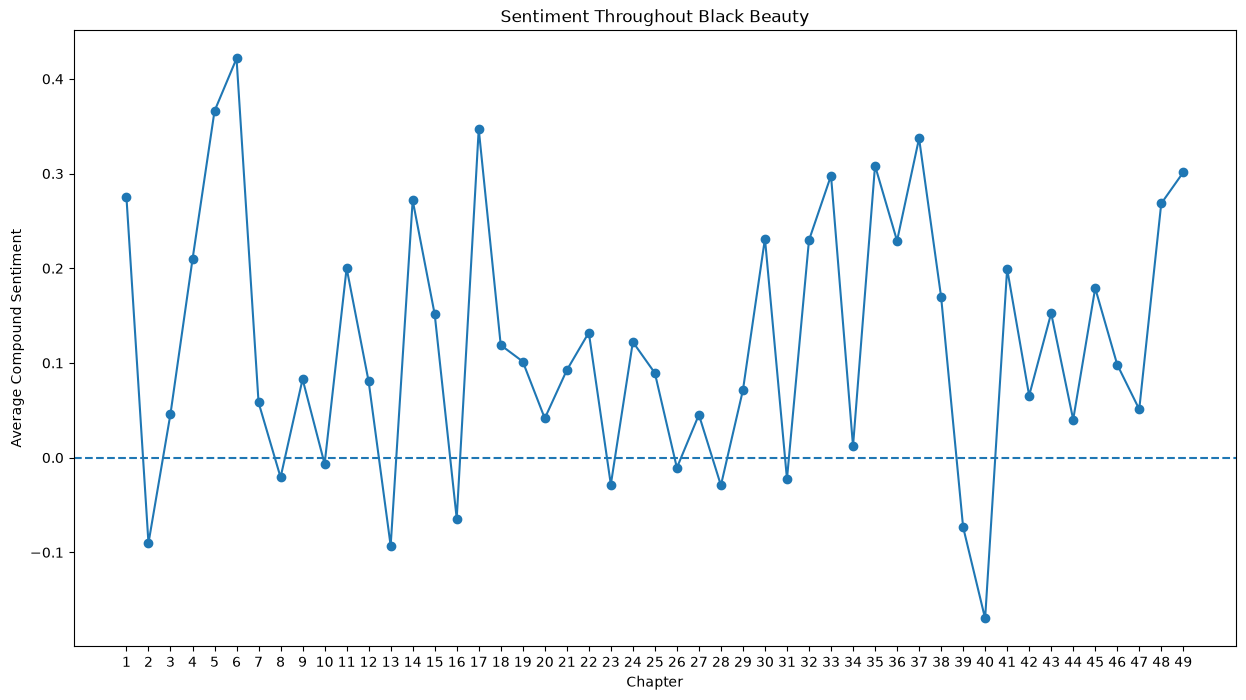

In [12]:
plt.figure(figsize=(15, 8))
plt.plot(np.array(Black_beauty_df.index) + 1, Black_beauty_df['compound'], marker='o')
plt.axhline(0, linestyle='--')
plt.title("Sentiment Throughout Black Beauty")
plt.xlabel("Chapter")
plt.ylabel("Average Compound Sentiment")
plt.xticks(np.arange(1, Black_beauty_df.shape[0] + 1))
plt.show()